In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pickle

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rapol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv(r"C:\Users\rapol\Downloads\spam.csv", encoding="latin-1")

df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

df.shape

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


403

In [6]:
df = df.drop_duplicates()

df.shape

(5169, 2)

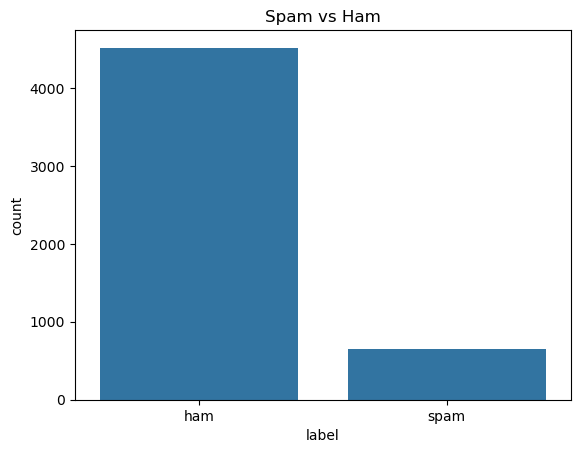

In [7]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

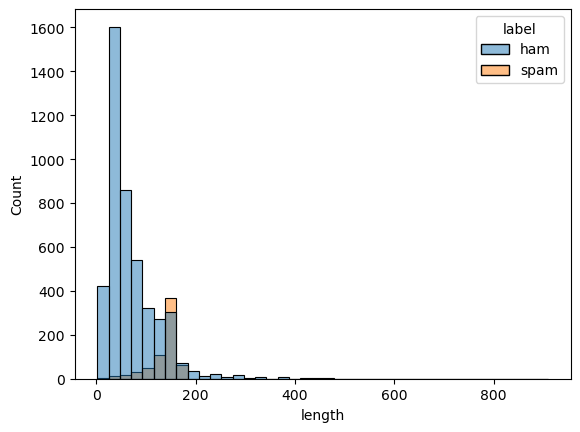

In [8]:
df["length"] = df["message"].apply(len)

sns.histplot(data=df, x="length", hue="label", bins=40)

plt.show()

In [9]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

stemmer = PorterStemmer()

def preprocess(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

# Apply preprocessing
df["processed_message"] = df["message"].apply(preprocess)

# Display first 5 rows
df.head()

,label,message,length,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goe usf live around though


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=3000)

# Convert text into numerical features
X = tfidf.fit_transform(df["processed_message"])

# Convert labels into numbers
y = df["label"].map({"ham": 0, "spam": 1})

print("Shape of TF-IDF Matrix:", X.shape)
print("Labels Shape:", y.shape)

Shape of TF-IDF Matrix: (5169, 3000)
Labels Shape: (5169,)


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4135, 3000)
Testing Data: (1034, 3000)


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Print results
print("===== Naive Bayes Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

===== Naive Bayes Results =====
Accuracy: 0.9758220502901354

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.83      0.91       145

    accuracy                           0.98      1034
   macro avg       0.99      0.91      0.95      1034
weighted avg       0.98      0.98      0.97      1034

Confusion Matrix:
[[889   0]
 [ 25 120]]


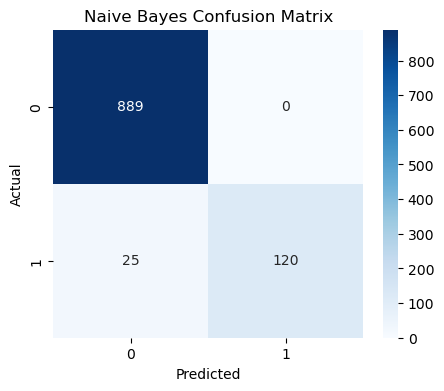

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Results
print("===== Logistic Regression Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

===== Logistic Regression Results =====
Accuracy: 0.9564796905222437

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       889
           1       0.95      0.73      0.82       145

    accuracy                           0.96      1034
   macro avg       0.95      0.86      0.90      1034
weighted avg       0.96      0.96      0.95      1034

Confusion Matrix:
[[883   6]
 [ 39 106]]


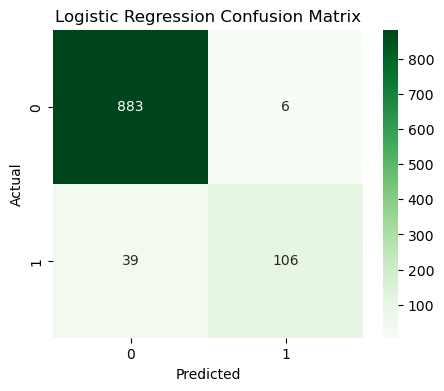

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ]
})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.975822
1  Logistic Regression  0.956480


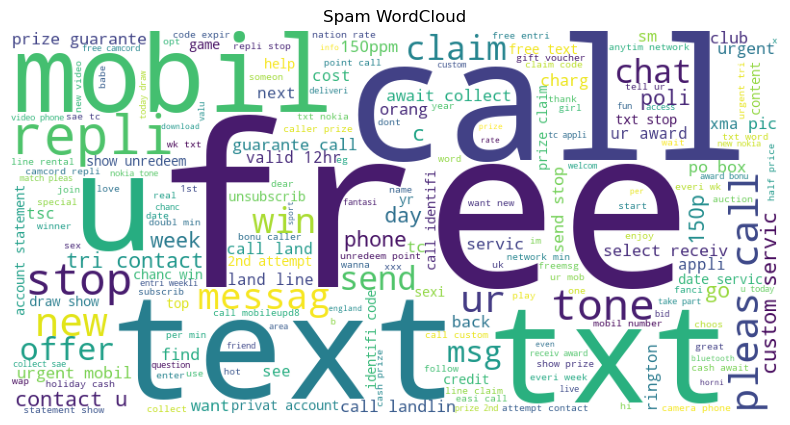

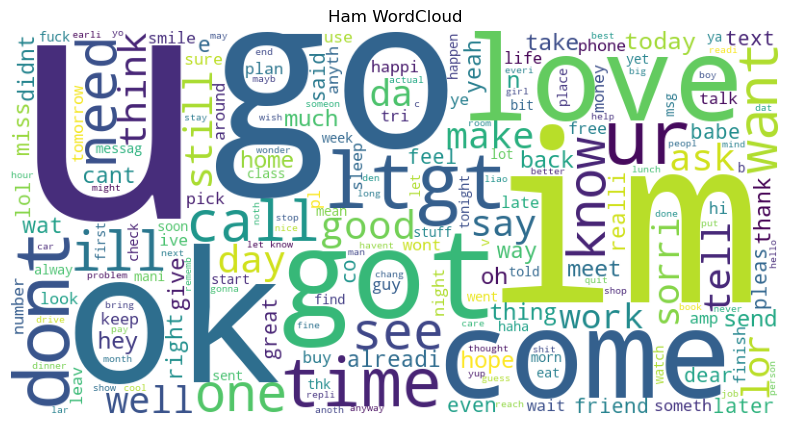

In [17]:
from wordcloud import WordCloud

# Spam messages
spam_text = " ".join(df[df["label"] == "spam"]["processed_message"])

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()

# Ham messages
ham_text = " ".join(df[df["label"] == "ham"]["processed_message"])

ham_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

In [18]:
import pickle

# Save Logistic Regression model
with open("spam_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model and TF-IDF Vectorizer saved successfully!")

Model and TF-IDF Vectorizer saved successfully!
